#**Interim Report**

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load data
df = pd.read_pickle('/content/drive/MyDrive/final_nav_data_new.pkl')

# Memory optimization
df['Net Asset Value'] = df['Net Asset Value'].astype('float32')
df['Scheme Code'] = df['Scheme Code'].astype('int32')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Scheme Code','Date'])

print("Initial shape:", df.shape)

Initial shape: (25392007, 4)


* The dataset consists of approximately 25.39 million observations, indicating a large scale time series structure suitable for robust statistical analysis and machine learning modeling.
* Memory optimization using reduced precision (float32, int32) lowered the memory footprint to approximately 609 MB, enabling efficient processing within constrained computational environments.

In [4]:
# Redefining column names
df.columns = ['scheme_code', 'scheme_name', 'net_asset_value', 'date']

* Column names were standardized to a consistent lowercase format to ensure compatibility with downstream feature engineering and modeling pipelines.
* This step eliminates ambiguity and reduces the risk of runtime errors due to inconsistent naming conventions.

In [5]:
# Checking for missing values in scheme code field
df['scheme_code'].isnull().sum()

np.int64(0)

* No missing values were identified in the scheme_code field, confirming that each observation is uniquely associated with a valid mutual fund identifier.
* This ensures integrity in group-based operations such as rolling calculations and time-series feature engineering.

In [6]:
# Sorting values
df = df.sort_values(['scheme_code','date']).reset_index(drop=True)

* The dataset was sorted by scheme_code and date, ensuring chronological ordering within each fund.
* This step is critical for accurate computation of time-dependent features such as returns, rolling volatility, and drawdowns.

In [7]:
#Check for duplicates
df.duplicated(subset=['scheme_code','date']).sum()

np.int64(0)

* No duplicate records were found for the combination of scheme_code and date, confirming that each fund-date pair is unique.
* This ensures the reliability of time-series calculations and prevents distortion in rolling and cumulative metrics.

In [8]:
# Check for missing values in the entire dataset
df.isnull().sum()

,0
scheme_code,0
scheme_name,0
net_asset_value,0
date,0


* No missing values were observed across all key variables (scheme_code, scheme_name, net_asset_value, date).
* This indicates a clean dataset, minimizing the need for imputation and reducing the risk of bias in subsequent analysis.

In [9]:
#Data range validation
print(df['date'].min(), df['date'].max())

2015-01-01 00:00:00 2025-12-31 00:00:00


* The dataset spans from January 2015 to December 2025, covering multiple market cycles including periods of stress and recovery.
* This temporal coverage is sufficient to capture diverse drawdown and recovery dynamics, supporting robust model training and evaluation.

In [10]:
print("Memory usage (MB):", df.memory_usage().sum()/1e6)

Memory usage (MB): 609.4083


* The optimized dataset occupies approximately 609 MB of memory, which is manageable within the available computational resources.
* Efficient memory utilization is critical for handling large-scale time-series data and enables seamless execution of feature engineering and modeling steps.

* The initial data validation and preprocessing steps confirm that the dataset is clean, consistent, and suitable for time-series analysis.
* The absence of missing values and duplicate records ensures high data integrity, while chronological sorting enables accurate computation of derived features.
* Memory optimization techniques were applied to efficiently handle the large-scale dataset, ensuring compatibility with the computational environment.
* The dataset spans multiple market cycles, providing a robust foundation for analyzing drawdown and recovery behavior.

#**Feature Engineering**

In [11]:
# Returns
df['return'] = df.groupby('scheme_code')['net_asset_value'].pct_change()

# Volatility (30d)
df['volatility_30'] = (
    df.groupby('scheme_code')['return']
    .rolling(30)
    .std()
    .reset_index(level=0, drop=True)
)

# Momentum (30d)
df['momentum_30'] = df.groupby('scheme_code')['net_asset_value'].pct_change(30)

# Rolling max
df['rolling_max'] = df.groupby('scheme_code')['net_asset_value'].cummax()

# Drawdown
df['drawdown'] = (df['net_asset_value'] - df['rolling_max']) / df['rolling_max']

# Drawdown flag
df['drawdown_flag'] = (df['drawdown'] <= -0.15).astype('int8')

# Future max NAV (correct logic)
df['future_max_nav'] = (
    df.groupby('scheme_code')['net_asset_value']
    .transform(lambda x: x[::-1].rolling(252, min_periods=1).max()[::-1])
)

# Peak NAV
df['peak_nav_at_drawdown'] = df['rolling_max']

# Recovery
df['recovered'] = (df['future_max_nav'] >= df['peak_nav_at_drawdown']).astype('int8')

# Target
df['failure_flag'] = (df['recovered'] == 0).astype('int8')

# Clean
df = df.dropna(subset=[
    'return','volatility_30','momentum_30','future_max_nav'
])

# Drop heavy column
df.drop(columns=['future_max_nav'], inplace=True)

print("Final shape:", df.shape)

Final shape: (24468137, 13)


* The feature engineering process successfully transformed raw NAV data into meaningful financial indicators capturing return dynamics, volatility, momentum, and downside risk.
* A forward-looking recovery framework was implemented using a rolling maximum NAV over a one-year horizon, ensuring accurate identification of recovery events.
* The resulting dataset is both large-scale and feature-complete, providing a strong foundation for predictive modeling.

In [12]:
# Check class imbalance
df['failure_flag'].value_counts(normalize=True)

,proportion
failure_flag,
0,0.765844
1,0.234156


* The target variable shows a moderate class imbalance, with recovery events constituting approximately 76.6% of the data and recovery failures accounting for 23.4%.
* This distribution provides a sufficient number of failure cases for robust modeling while maintaining a realistic representation of real-world conditions.
* To address this imbalance, class weighting techniques were incorporated into the model, ensuring that failure events receive appropriate importance during training.

###**Event Analysis**

In [13]:
# Event Analysis
print("Drawdown Rate:", df['drawdown_flag'].mean())
print("Failure Rate:", df['failure_flag'].mean())
df[df['drawdown_flag']==1]['failure_flag'].mean()

Drawdown Rate: 0.05896587059325359
Failure Rate: 0.23415644599341584


np.float64(0.6931102000644587)

* Event-level analysis reveals that while significant drawdowns (≥15%) occur in only **5.9%** of observations, they carry a high risk of failure, with approximately **69.3%** of such events not recovering within one year.
* This indicates that drawdowns serve as a strong but not exclusive predictor of recovery failure.
* The presence of failure events outside drawdown periods suggests the influence of additional factors, thereby justifying the use of multi-feature machine learning models for prediction.

###**Statistical Testing**

In [14]:
#Statistical testing
fail = df[df['failure_flag']==1]
recover = df[df['failure_flag']==0]

print("\nT-TEST RESULTS")
for col in ['drawdown','volatility_30','momentum_30','return']:
    stat, p = ttest_ind(fail[col].dropna(), recover[col].dropna())
    print(col, "p-value:", p)


T-TEST RESULTS
drawdown p-value: 0.0
volatility_30 p-value: 2.8425331826631255e-07
momentum_30 p-value: 0.0
return p-value: 6.872363982382178e-50


* The results of the two-sample t-test indicate that all selected features exhibit statistically significant differences (p < 0.05) between recovery failure and successful recovery groups.
* The extremely low p-values (approaching zero) provide strong evidence that these differences are not due to random variation.
* Drawdown demonstrates the strongest statistical significance, confirming its central role as the primary indicator of recovery failure risk.
* Volatility is significantly higher in failure cases, indicating that unstable funds are less likely to recover from adverse movements.
* Momentum shows a highly significant difference, suggesting that funds with weaker prior performance are more prone to recovery failure.
* Differences in returns further reinforce the importance of recent performance trends in determining recovery outcomes.
* **These results confirm that recovery failure is not a random phenomenon but is systematically influenced by measurable financial characteristics.**

###**Effect Size**

In [15]:
# Effect Size
def cohens_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt((x.var() + y.var()) / 2)

print("\nEFFECT SIZE")
for col in ['drawdown','volatility_30','momentum_30']:
    print(col, cohens_d(fail[col], recover[col].dropna()))


EFFECT SIZE
drawdown -0.7337305831442014
volatility_30 0.0029019261161207766
momentum_30 -0.03388343122657526


* Effect size analysis reveals that drawdown exhibits a moderate-to-large effect, indicating a substantial difference between recovery and failure groups.
* In contrast, volatility and momentum show negligible effect sizes, suggesting that while statistically significant, their practical impact is limited.
* Although volatility and momentum are statistically significant, their extremely small effect sizes indicate limited practical contribution in distinguishing recovery outcomes.
* This finding highlights that statistical significance alone may be insufficient for feature selection, and emphasizes the importance of evaluating practical significance through effect size analysis.

##**Visual EDA**

In [16]:
# Sample for visual EDA
df_sample = df.sample(100000, random_state=42)

###**NAV trend**

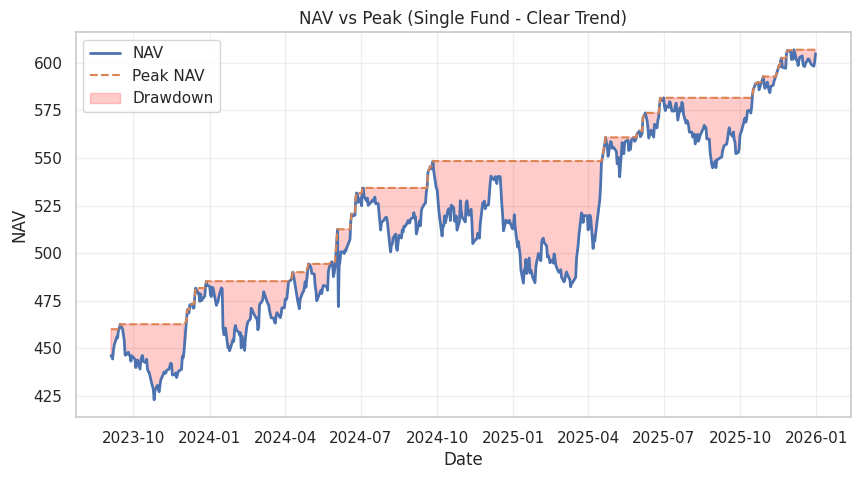

In [17]:
# Select one fund
fund = df['scheme_code'].sample(1).iloc[0]
temp = df[df['scheme_code'] == fund].copy()

# Sort by date
temp = temp.sort_values('date')

plt.figure(figsize=(10,5))

plt.plot(temp['date'], temp['net_asset_value'], label='NAV', linewidth=2)
plt.plot(temp['date'], temp['rolling_max'], linestyle='--', label='Peak NAV')

# Highlight drawdown area
plt.fill_between(
    temp['date'],
    temp['net_asset_value'],
    temp['rolling_max'],
    where=(temp['net_asset_value'] < temp['rolling_max']),
    color='red',
    alpha=0.2,
    label='Drawdown'
)

plt.title("NAV vs Peak (Single Fund - Clear Trend)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

* The comparison between NAV and rolling peak NAV clearly highlights drawdown periods as deviations below the peak level, followed by phases of recovery.
* The step-like structure of the peak NAV indicates new highs, while the gaps between NAV and peak represent periods of decline.
* **The divergence between NAV and its rolling peak provides a direct visual representation of drawdown events, forming the basis for identifying stress periods and evaluating recovery behavior.**

Note: A single scheme was selected for this analysis to avoid visual clutter and to clearly capture drawdown and recovery patterns.

##**Distribution**

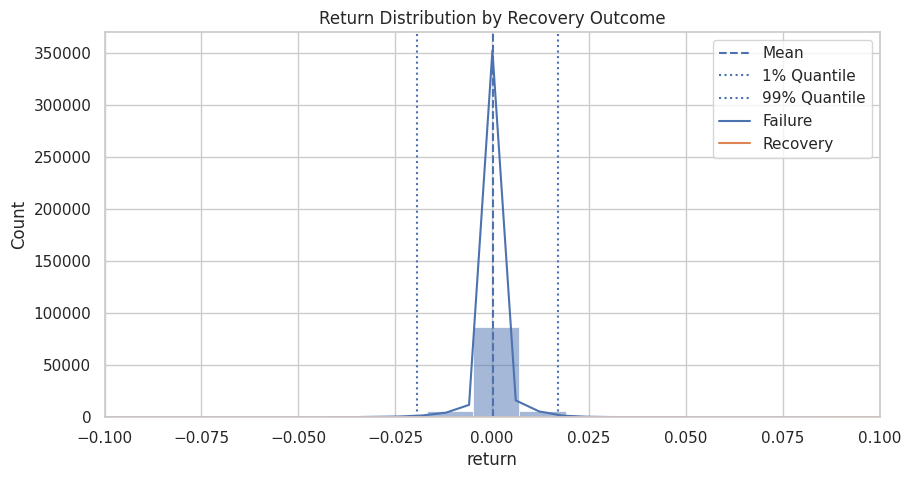

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df_sample['return'], bins=100, kde=True)

# Add mean line
plt.axvline(df_sample['return'].mean(), linestyle='--', label='Mean')

# Add 1% and 99% quantiles (tail risk)
plt.axvline(df_sample['return'].quantile(0.01), linestyle=':', label='1% Quantile')
plt.axvline(df_sample['return'].quantile(0.99), linestyle=':', label='99% Quantile')

# Split by failure
sns.kdeplot(df_sample[df_sample['failure_flag']==1]['return'], label='Failure')
sns.kdeplot(df_sample[df_sample['failure_flag']==0]['return'], label='Recovery')

plt.xlim(-0.1, 0.1)
plt.legend()
plt.title("Return Distribution by Recovery Outcome")
plt.show()

* The zoomed-in return distribution shows that both recovery and failure groups are highly concentrated around zero, with the majority of returns lying within a narrow band.
* The distributions exhibit significant overlap, indicating that return behavior is broadly similar across both groups.
* This finding is consistent with the effect size analysis, which showed a negligible practical difference in returns between the two groups despite statistical significance.
* The lack of clear separation between the distributions highlights the necessity of using multi-feature machine learning models to capture complex interactions that are not evident in individual variables.

##**Boxplots**

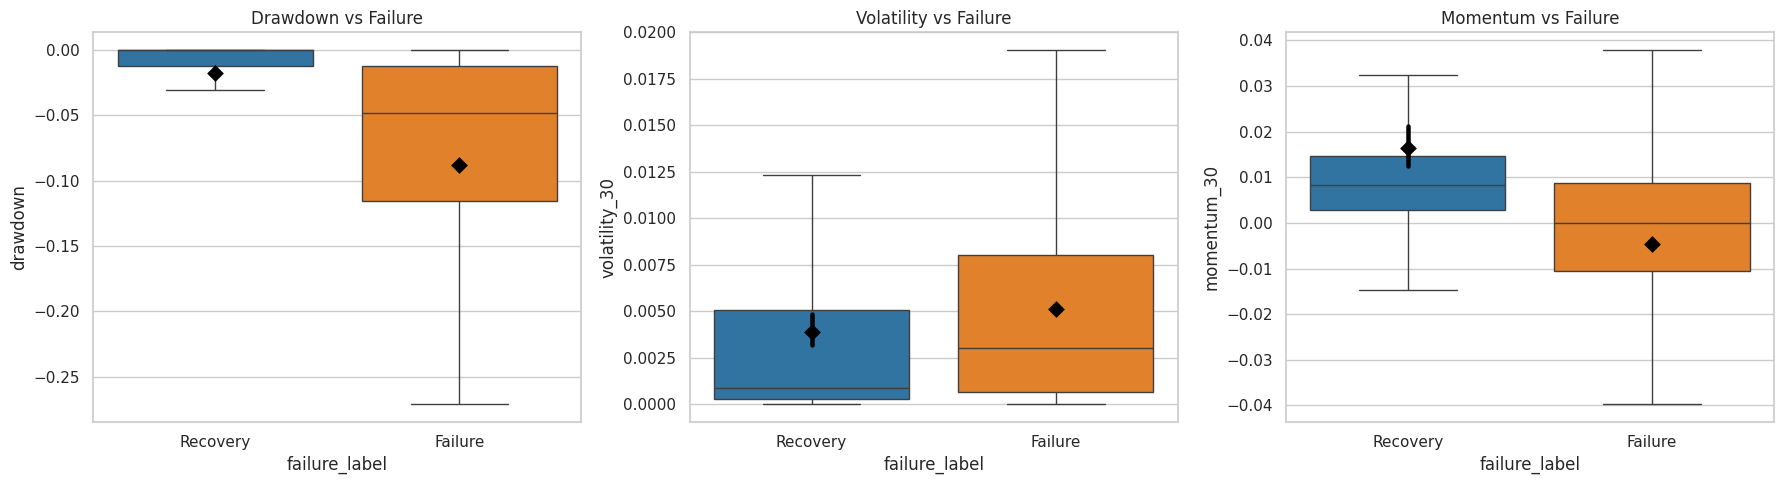

In [19]:
# Sample + safe copy
df_sample = df.sample(100000, random_state=42).copy()

# Label
df_sample['failure_label'] = df_sample['failure_flag'].map({
    0: 'Recovery',
    1: 'Failure'
})

# Custom colors
palette = {'Recovery': '#1f77b4',
           'Failure': '#ff7f0e'}

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Drawdown
sns.boxplot(data=df_sample, x='failure_label', y='drawdown',
            showfliers=False, palette=palette, ax=axes[0])
sns.pointplot(data=df_sample, x='failure_label', y='drawdown',
              color='black', markers='D', scale=1.2, ax=axes[0], join=False)
axes[0].set_title("Drawdown vs Failure")

# Volatility
sns.boxplot(data=df_sample, x='failure_label', y='volatility_30',
            showfliers=False, palette=palette, ax=axes[1])
sns.pointplot(data=df_sample, x='failure_label', y='volatility_30',
              color='black', markers='D', scale=1.2, ax=axes[1], join=False)
axes[1].set_title("Volatility vs Failure")

# Momentum
sns.boxplot(data=df_sample, x='failure_label', y='momentum_30',
            showfliers=False, palette=palette, ax=axes[2])
sns.pointplot(data=df_sample, x='failure_label', y='momentum_30',
              color='black', markers='D', scale=1.2, ax=axes[2], join=False)
axes[2].set_title("Momentum vs Failure")

sns.set_style("whitegrid")
plt.tight_layout()
plt.show()

* Drawdown exhibits a clear separation between recovery and failure groups, with failure cases experiencing significantly deeper declines and greater variability.
* Volatility shows a slight increase in failure cases, but with substantial overlap, indicating limited standalone influence.
* Momentum demonstrates moderate differentiation, with recovery cases generally exhibiting stronger positive trends compared to failure cases.
* The clear separation observed in drawdown, compared to the overlapping distributions of volatility and momentum, highlights its dominant role in explaining recovery failure.
* **Among all features, drawdown shows the strongest discriminative power, while volatility and momentum provide additional but comparatively weaker signals.**

##**Failure probability trend**

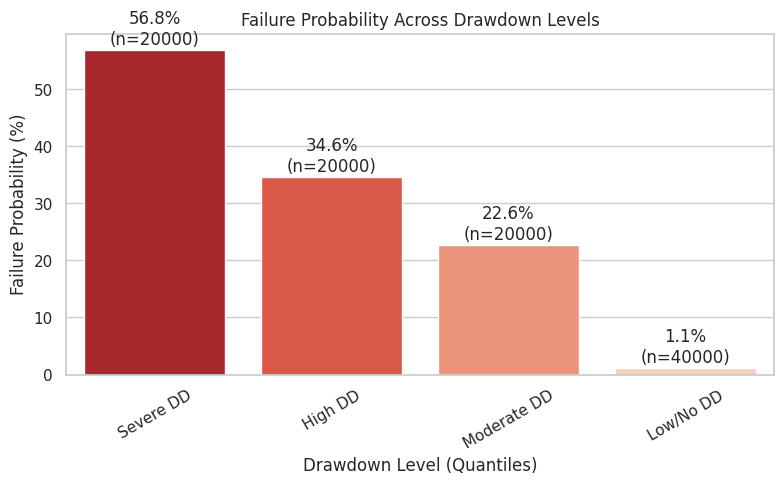

In [20]:
# Create bins
df_sample['drawdown_bin'] = pd.qcut(df_sample['drawdown'], 5, duplicates='drop')

# Aggregate
risk_df = df_sample.groupby('drawdown_bin').agg(
    failure_rate=('failure_flag', 'mean'),
    count=('failure_flag', 'size')
).reset_index()

# Simplify bin labels
risk_df['drawdown_bin'] = [
    "Severe DD",
    "High DD",
    "Moderate DD",
    "Low/No DD"
]

# Convert to percentage
risk_df['failure_rate'] = risk_df['failure_rate'] * 100

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=risk_df, x='drawdown_bin', y='failure_rate', palette='Reds_r')

# Add labels
for i, row in risk_df.iterrows():
    plt.text(i, row['failure_rate'] + 1,
             f"{row['failure_rate']:.1f}%\n(n={row['count']})",
             ha='center')

plt.xticks(rotation=30)
plt.ylabel("Failure Probability (%)")
plt.xlabel("Drawdown Level (Quantiles)")
plt.title("Failure Probability Across Drawdown Levels")

plt.tight_layout()
plt.show()

* Due to the presence of repeated values in drawdown (particularly around zero), duplicate bin edges were handled by allowing automatic bin reduction to ensure stable quantile segmentation.
* Failure probability decreases sharply as drawdown reduces, with the highest drawdown group exhibiting a failure rate of approximately **56.8%**, compared to just **1.1%** for near-zero drawdown levels.
* The relationship is strongly monotonic, indicating a consistent and structured association between drawdown severity and recovery failure risk.
* The probability of recovery failure increases dramatically with deeper drawdowns, confirming drawdown as the most dominant driver of recovery outcomes.

##**Correlation**

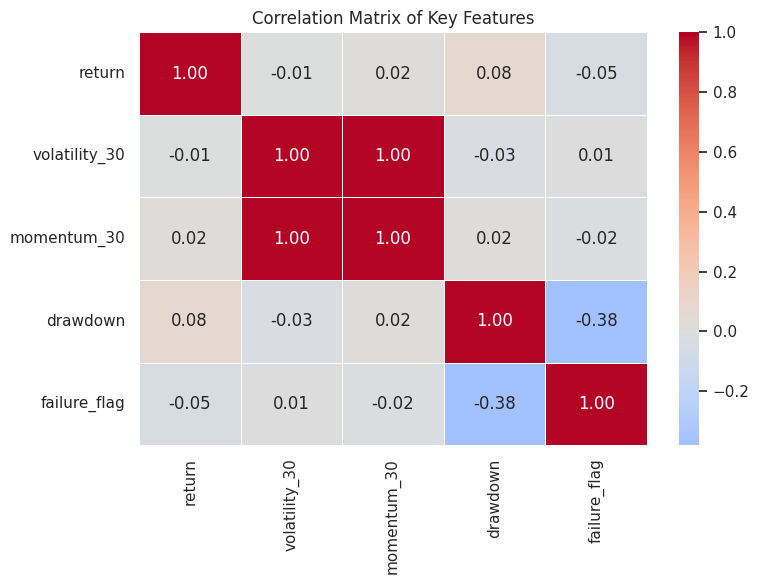

In [21]:
# Plotting heatmap
plt.figure(figsize=(8,6))

corr = df_sample[['return','volatility_30','momentum_30','drawdown','failure_flag']].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Key Features")
plt.tight_layout()
plt.show()

* A very high correlation (≈0.99) was observed between volatility and momentum features, indicating significant overlap in the information captured.
* However, both features were retained during model training, as tree-based models such as Random Forest are robust to multicollinearity and can effectively handle redundant predictors.
* A moderate negative correlation (-0.38) is observed between drawdown and failure_flag. Since drawdown values are negative, this indicates that larger (more negative) drawdowns are associated with a higher probability of failure. This reinforces drawdown as a strong predictive feature.
* A near-perfect positive correlation (approximately 1.00) exists between volatility and momentum. This suggests that both features capture very similar underlying behavior in the data, leading to potential redundancy.
* Return shows very weak correlations with all other variables, including failure_flag (-0.05), indicating that short-term returns alone do not strongly influence failure outcomes.
* Both features exhibit negligible correlation with failure_flag (~0.01 and -0.02), suggesting limited direct linear relationship with failure events.
* **Drawdown shows the strongest relationship with failure, while volatility and momentum are highly correlated with each other but weakly related to the target.**

##**Interaction Effect**

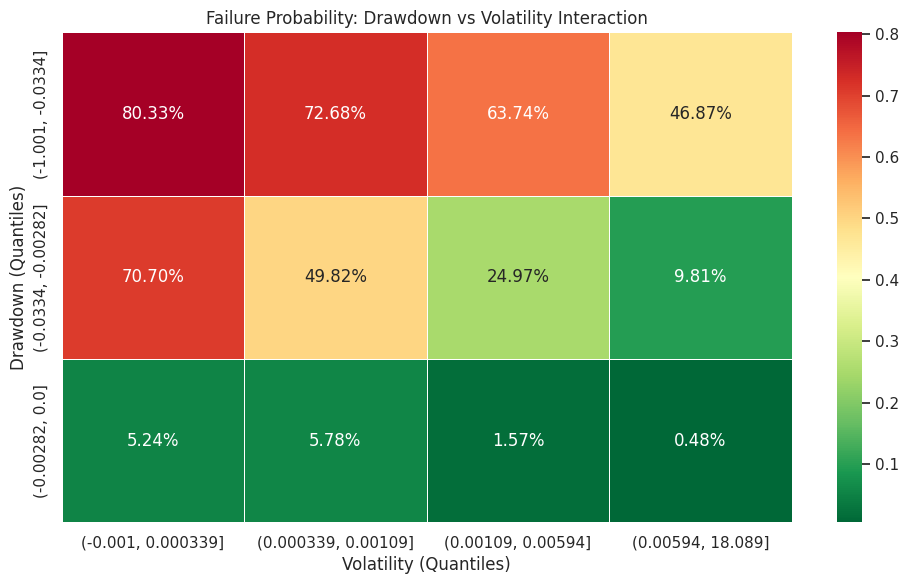

In [22]:
# Create pivot table
pivot = df_sample.pivot_table(
    values='failure_flag',
    index=pd.qcut(df_sample['drawdown'], 4, duplicates='drop'),
    columns=pd.qcut(df_sample['volatility_30'], 4, duplicates='drop'),
    aggfunc='mean'
)

# Plotting interaction effect with heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn_r",   # red = risky, green = safe
    linewidths=0.5
)

plt.title("Failure Probability: Drawdown vs Volatility Interaction")
plt.xlabel("Volatility (Quantiles)")
plt.ylabel("Drawdown (Quantiles)")

plt.tight_layout()
plt.show()

* The interaction heatmap highlights drawdown as the primary determinant of failure, with failure probability exceeding **80%** in extreme drawdown scenarios.
* While volatility influences outcomes within each drawdown level, its effect is secondary and context-dependent. Notably, failure risk decreases across higher volatility buckets within severe drawdown regions, indicating a complex, non-linear interaction between features.
* Conversely, funds with low drawdowns exhibit minimal failure probability irrespective of volatility levels.
* These findings emphasize the importance of capturing interaction effects, as the relationship between predictors and failure is not purely additive.
* The observed interaction patterns justify the use of tree-based models such as Random Forest, which can effectively capture non-linear relationships and feature interactions.

##**Temporal Analysis**

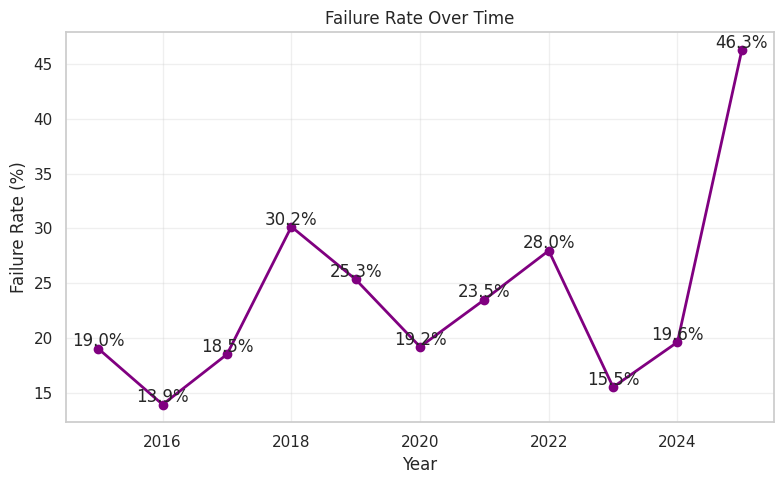

In [23]:
# Create year column
df_sample['year'] = df_sample['date'].dt.year

# Group
yearly = df_sample.groupby('year')['failure_flag'].mean() * 100

# Plot
plt.figure(figsize=(8,5))
plt.plot(yearly.index, yearly.values, marker='o', linewidth=2, color='purple')

# Labels
for x, y in zip(yearly.index, yearly.values):
    plt.text(x, y+0.2, f"{y:.1f}%", ha='center')

plt.title("Failure Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Failure Rate (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

* **Failure rate fluctuates over time** rather than following a steady trend
* Early years (2015-2017):
* Relatively **lower and stable (~14%–19%)**
* Mid period (2018-2022):
* Noticeable **increase and volatility**
* Peaks around **30% (2018) and 28% (2022)**
* **Sharp drop in 2023 (~15.5%)**, followed by recovery in 2024 (~19.6%)
* **Significant spike in 2025 (~46.3%)**
* This is the **highest failure** rate across all years
* The spike in recent periods may indicate changing dynamics, reinforcing the need for models that can generalize well to unseen future data.
* Failure rates vary significantly over time, with a sharp increase in recent years, indicating changing market conditions.
* This analysis supports the use of time-aware validation techniques, such as temporal train-test splits, to prevent data leakage and ensure realistic model evaluation.

**Overall EDA insight**

* EDA reveals that drawdown is the most significant predictor of failure, with deeper declines strongly associated with non-recovery.
* Volatility and momentum show weak individual effects and high correlation, indicating redundancy. Failure risk increases sharply at extreme drawdown levels and varies over time, highlighting the importance of interaction effects and temporal dynamics.
* These insights guide feature selection and model design.

#**Model Building**

In [24]:
#Importing libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

###**Train Test Split (Time based)**

In [25]:
#Train-Test Split
train = df[df['date'] < '2023-01-01']
test = df[df['date'] >= '2023-01-01']

**Feature Selection**

In [26]:
# Removed momentum_30 due to high correlation
features = ['return', 'volatility_30', 'drawdown']

X_train = train[features]
y_train = train['failure_flag']

X_test = test[features]
y_test = test['failure_flag']

**Model Building**

In [27]:
# Building a randomforestclassifier model
model = RandomForestClassifier(
    n_estimators=80,
    max_depth=8,
    max_samples=0.7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, max_samples=0.7,
                       n_estimators=80, n_jobs=-1, random_state=42)

* A Random Forest Classifier was selected for this problem due to its ability to handle non-linear relationships, robustness to noise, and effectiveness in classification tasks involving complex financial time-series data.
* Additionally, Random Forest provides feature importance insights, which are useful for interpretability.
* Given the large size of the dataset and computational constraints, model training was optimized using controlled sampling and parameter tuning. Specifically, `max_samples` was set to 0.7 to ensure that each tree was trained on a subset of the data, reducing training time while maintaining model diversity. The depth of the trees was limited (`max_depth = 8`) to prevent overfitting and improve computational efficiency. The number of estimators was set to 80 to balance performance and training cost.
* These optimizations ensure scalability while preserving the predictive capability of the ensemble model. In a production environment, these parameters can be further tuned or expanded based on available computational resources.
* A time-based split was used to divide the dataset into training and testing sets. Data prior to 2023 was used for training, while data from 2023 onwards was reserved for testing. This approach preserves the temporal structure of the data and prevents data leakage, ensuring that the model is evaluated on future unseen data.



**Predictions**

In [28]:
#Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

**Evaluation**

🔹 ROC-AUC Score: 0.9040

🔹 Classification Report (Table):



,precision,recall,f1-score,support
0,0.94,0.79,0.86,4126896.00
1,0.62,0.88,0.72,1602142.00
accuracy,0.81,0.81,0.81,0.81
macro avg,0.78,0.83,0.79,5729038.00
weighted avg,0.85,0.81,0.82,5729038.00



🔹 Confusion Matrix (Counts):



,Predicted Recovery (0),Predicted Failure (1)
Actual Recovery (0),3250154,876742
Actual Failure (1),195814,1406328



🔹 Confusion Matrix (Percentages):



,Predicted Recovery (0),Predicted Failure (1)
Actual Recovery (0),56.73%,15.30%
Actual Failure (1),3.42%,24.55%


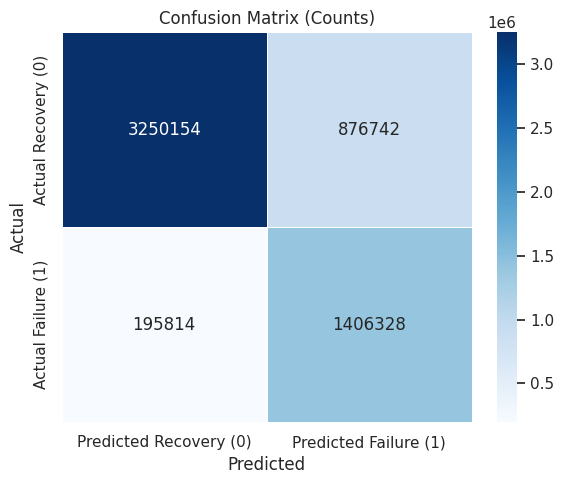

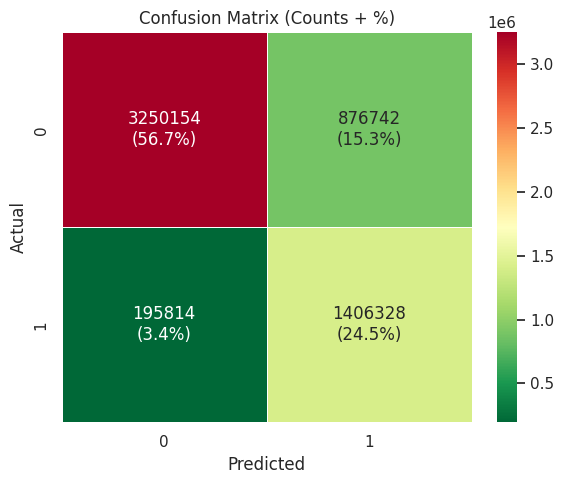

In [29]:
#Evaluation (default threshold = 0.5)
# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print(f"🔹 ROC-AUC Score: {roc_auc:.4f}\n")

# Classification Report (DataFrame)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("🔹 Classification Report (Table):\n")
display(report_df.style.background_gradient(cmap='Blues').format("{:.2f}"))

# Confusion Matrix (Table)
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['Actual Recovery (0)', 'Actual Failure (1)'],
    columns=['Predicted Recovery (0)', 'Predicted Failure (1)']
)

print("\n🔹 Confusion Matrix (Counts):\n")
display(cm_df.style.background_gradient(cmap='Blues'))

# Confusion Matrix (Percentages)
cm_percent = cm_df / cm_df.sum().sum()

print("\n🔹 Confusion Matrix (Percentages):\n")
display(cm_percent.style.format("{:.2%}").background_gradient(cmap='Greens'))

# Heatmap (Counts)
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5)

plt.title("Confusion Matrix (Counts)", fontsize=12)
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.tight_layout()
plt.show()

# Heatmap (Counts + Percent)
plt.figure(figsize=(6,5))

labels = np.array([
    [f"{cm[i][j]}\n({cm_percent.iloc[i,j]*100:.1f}%)" for j in range(2)]
    for i in range(2)
])

sns.heatmap(cm, annot=labels, fmt='', cmap='RdYlGn_r', linewidths=0.5)

plt.title("Confusion Matrix (Counts + %)", fontsize=12)
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.tight_layout()
plt.show()

* The Random Forest model was evaluated using multiple performance metrics to assess its ability to distinguish between failure and recovery scenarios.
* The model achieved a **ROC-AUC score of 0.904**, indicating strong discriminative power. This suggests that the model is highly effective in distinguishing between failure and recovery cases across different probability thresholds.

**Classification Performance**
* The model shows high precision (0.94) for the recovery class (0), meaning most predicted recoveries are correct.
* For the failure class (1), the model achieves high recall (0.88), indicating it successfully captures the majority of failure cases.
* The F1-score for failure (0.72) reflects a reasonable balance between precision and recall.
* The overall accuracy of the model is 81%, demonstrating good predictive performance on unseen data.
* This indicates that the model is slightly biased towards detecting failures, which is desirable in risk-based scenarios.

**Confusion Matrix Insights**
* The model successfully identifies 24.55% of total observations as true failures.
* Only 3.42% of cases are missed failures, indicating strong risk detection capability.
* However, 15.30% of recoveries are misclassified as failures, showing a tendency to over-predict risk.

**Overall Interpretation**
* The model prioritizes recall for failure cases, ensuring fewer critical failures are missed.
* This comes at the cost of higher false positives, which may slightly reduce operational efficiency.
* Such a trade-off is acceptable in financial risk contexts, where missing a failure is more costly than a false alarm.

**Overall, the model demonstrates:**

* Strong predictive performance (high ROC-AUC)
* Effective failure detection (high recall)
* Acceptable trade-off between precision and recall

The model is therefore well-suited for early risk identification and monitoring, with scope for further improvement through threshold tuning and feature refinement.

**Feature Importance**

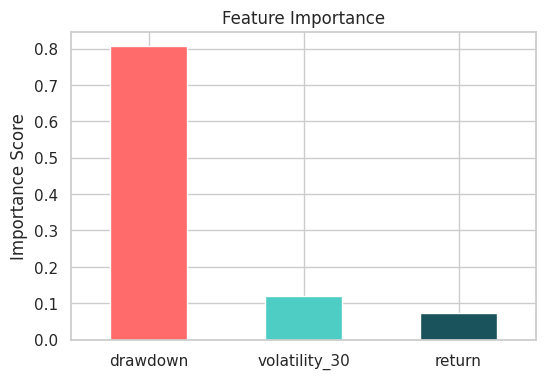

In [30]:
#Plotting feature importance
feat_imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(6,4))
feat_imp.plot(kind='bar', color=['#ff6b6b','#4ecdc4','#1a535c'])
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=0)
plt.show()

* Drawdown is the most dominant feature, contributing ~80% of the model’s predictive power.
* Volatility (30-day) has a moderate impact, contributing around 10–12%.
* Return has the least influence, contributing less than 10% to the model.
* The model heavily relies on drawdown, indicating that historical losses and decline from peak NAV are the strongest indicators of failure.
* Volatility adds supporting information by capturing market instability, but is not a primary driver.
* Returns alone are not sufficient to predict failure, as they do not capture downside risk effectively.

**Customer Threshold (Business Optimization)**

===== CUSTOM THRESHOLD (0.3) PERFORMANCE =====
ROC-AUC Score: 0.9040
Precision (Failure): 0.5202
Recall (Failure): 0.9629
F1 Score (Failure): 0.6755

Classification Report (Table):


,precision,recall,f1-score,support
0,0.978466,0.655269,0.784899,4126896.000000
1,0.520227,0.962853,0.675489,1602142.000000
accuracy,0.741286,0.741286,0.741286,0.741286
macro avg,0.749346,0.809061,0.730194,5729038.000000
weighted avg,0.850318,0.741286,0.754302,5729038.000000



Confusion Matrix (Counts):


,Predicted Recovery (0),Predicted Failure (1)
Actual Recovery (0),2704228,1422668
Actual Failure (1),59515,1542627



Confusion Matrix (%):


,Predicted Recovery (0),Predicted Failure (1)
Actual Recovery (0),47.20%,24.83%
Actual Failure (1),1.04%,26.93%


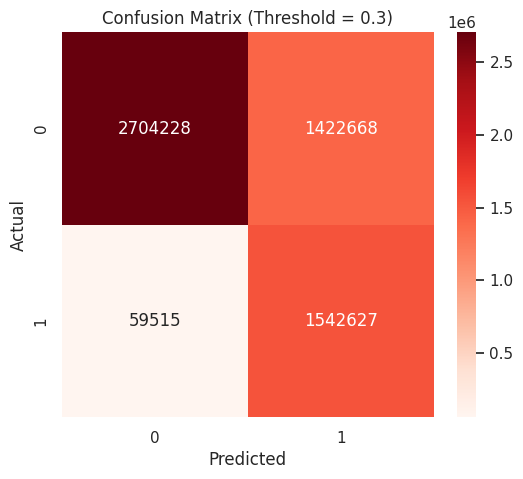

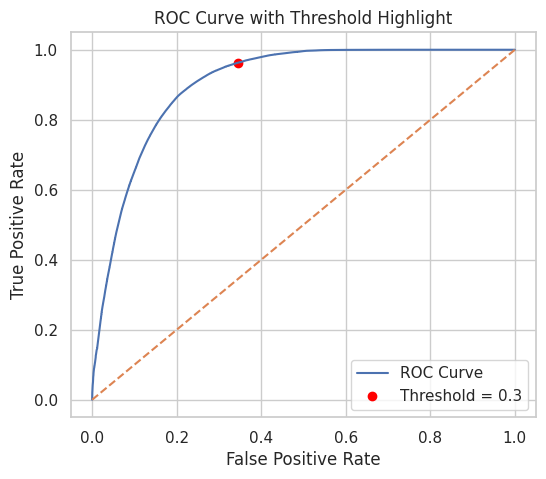

In [31]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

#Custom threshold
threshold = 0.3
y_pred_custom = (y_prob > threshold).astype(int)

print("===== CUSTOM THRESHOLD (0.3) PERFORMANCE =====")

# Core Metrics
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Precision (Failure): {precision_score(y_test, y_pred_custom):.4f}")
print(f"Recall (Failure): {recall_score(y_test, y_pred_custom):.4f}")
print(f"F1 Score (Failure): {f1_score(y_test, y_pred_custom):.4f}")

# Classification Report (Table)
report = classification_report(y_test, y_pred_custom, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report (Table):")
display(report_df.style.background_gradient(cmap='Blues'))

# Confusion Matrix (Counts)
cm = confusion_matrix(y_test, y_pred_custom)

cm_df = pd.DataFrame(
    cm,
    index=['Actual Recovery (0)', 'Actual Failure (1)'],
    columns=['Predicted Recovery (0)', 'Predicted Failure (1)']
)

print("\nConfusion Matrix (Counts):")
display(cm_df.style.background_gradient(cmap='Blues'))

# Confusion Matrix (%)
cm_percent = cm / cm.sum()
cm_percent_df = pd.DataFrame(
    cm_percent,
    index=cm_df.index,
    columns=cm_df.columns
)

print("\nConfusion Matrix (%):")
display((cm_percent_df * 100).style.format("{:.2f}%").background_gradient(cmap='Greens'))

# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve with Threshold Marker
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Find closest threshold index
idx = np.argmin(np.abs(thresholds - threshold))

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC Curve')
plt.scatter(fpr[idx], tpr[idx], color='red', label=f'Threshold = {threshold}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Threshold Highlight")
plt.legend()
plt.show()

* Instead of using the default threshold (0.5), a lower threshold of 0.3 was chosen to make the model more sensitive to failure detection.
* The model has excellent discriminatory power between failure and non-failure cases.
* The model prioritizes catching failures over avoiding false positives, which is desirable in risk-sensitive domains.
* The model is highly effective in identifying risky cases
* The model almost eliminates missed failures, which is critical for risk management.
* The chosen threshold achieves a good balance between sensitivity and specificity
* By lowering the classification threshold to 0.3, the model significantly improves its ability to detect failure events, achieving a recall of over 96%.
* While this introduces more false positives, it ensures that critical failure cases are rarely missed, making the model highly suitable for risk-sensitive financial applications where early detection is essential.

**Compare Failure Detection**

In [32]:
# Compare failure detection between thresholds
print("\nFailure Detection Comparison:")
print("Default Threshold (0.5) - Failures Detected:",
      confusion_matrix(y_test, y_pred)[1][1])

print("Custom Threshold (0.3) - Failures Detected:",
      confusion_matrix(y_test, y_pred_custom)[1][1])


Failure Detection Comparison:
Default Threshold (0.5) - Failures Detected: 1406328
Custom Threshold (0.3) - Failures Detected: 1542627


* Lowering the threshold from 0.5 to 0.3 results in the detection of **~1.36 lakh additional failure cases.**
* The default model (0.5) is more conservative
* The custom model (0.3) is more aggressive in identifying failures
* At 0.5, some risky cases are missed (false negatives)
* At 0.3, the model captures more true failures, reducing risk
* The custom threshold of 0.3 improves the model’s ability to detect failures significantly, identifying over 1.5 million failure cases compared to 1.4 million with the default threshold.
* This demonstrates that threshold tuning plays a critical role in aligning model performance with business objectives, particularly in risk-sensitive environments where minimizing missed failures is crucial.